Data Preprocessing

The goal of this notebook is to clean and transform the raw customer data into a format suitable for machine learning. This includes handling data quality issues, converting data types, encoding categorical variables, and preparing the dataset for model training.

In [154]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [155]:
# Lets investigate "TotalCharges" which should be int but is stored as String 
# Lets also look for missing values in it

df["TotalCharges"].dtype

<StringDtype(storage='python', na_value=nan)>

In [156]:
(df["TotalCharges"] == " ").sum()

np.int64(11)

In [157]:
# Lets take a look at who these customers are 

df[df["TotalCharges"] == " "]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


As visible, the tenure for these customers is 0, which means they are new customers and have not been charged yet. We can safely remove these rows from the dataset.

In [158]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [159]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [160]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [161]:
# drop the rows with missing values in TotalCharges
df.dropna(inplace=True)
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [162]:
# lets remove the customerID column as it is not useful for our analysis
df.drop(columns=["customerID"], inplace=True)

In [163]:
# Lets encode the target variable "Churn" to 0 and 1 for No and Yes respectively
df["Churn"] = df["Churn"].map(
    {"No": 0, "Yes": 1}
)

In [164]:
df["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [165]:
# Separate the features and target variable

X = df.drop("Churn", axis=1)

y = df["Churn"]

In [166]:
categorical_cols = X.select_dtypes(include="object").columns.tolist()

numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print(categorical_cols)
print(numerical_cols)

['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


/var/folders/hs/5tjjygrd7_xd6q2cfnmr5hlm0000gn/T/ipykernel_40155/2971393759.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include="object").columns.tolist()


In [167]:
# Lets do train-test-split 

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42,       # Ensures reproducibility
    stratify=y             # preserves the class distribution in both sets
    )

In [168]:
print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (5625, 19)
Testing Shape: (1407, 19)


In [169]:
print(y_train.value_counts(normalize=True))

print()

print(y_test.value_counts(normalize=True))

Churn
0    0.734222
1    0.265778
Name: proportion, dtype: float64

Churn
0    0.734186
1    0.265814
Name: proportion, dtype: float64


In [170]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [171]:
numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

In [172]:
categorical_transformer = Pipeline(
    steps=[
        ("encoder", OneHotEncoder(handle_unknown="ignore"))      # encoder safely ignores unseen categories
    ]
)

In [173]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

In [174]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test) # We only transform the test set, not fit it, to avoid data leakage

In [175]:
print(X_train_processed.shape)
print(X_test_processed.shape)
print(preprocessor.get_feature_names_out())

(5625, 45)
(1407, 45)
['num__SeniorCitizen' 'num__tenure' 'num__MonthlyCharges'
 'num__TotalCharges' 'cat__gender_Female' 'cat__gender_Male'
 'cat__Partner_No' 'cat__Partner_Yes' 'cat__Dependents_No'
 'cat__Dependents_Yes' 'cat__PhoneService_No' 'cat__PhoneService_Yes'
 'cat__MultipleLines_No' 'cat__MultipleLines_No phone service'
 'cat__MultipleLines_Yes' 'cat__InternetService_DSL'
 'cat__InternetService_Fiber optic' 'cat__InternetService_No'
 'cat__OnlineSecurity_No' 'cat__OnlineSecurity_No internet service'
 'cat__OnlineSecurity_Yes' 'cat__OnlineBackup_No'
 'cat__OnlineBackup_No internet service' 'cat__OnlineBackup_Yes'
 'cat__DeviceProtection_No' 'cat__DeviceProtection_No internet service'
 'cat__DeviceProtection_Yes' 'cat__TechSupport_No'
 'cat__TechSupport_No internet service' 'cat__TechSupport_Yes'
 'cat__StreamingTV_No' 'cat__StreamingTV_No internet service'
 'cat__StreamingTV_Yes' 'cat__StreamingMovies_No'
 'cat__StreamingMovies_No internet service' 'cat__StreamingMovies_Yes'


In [176]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [177]:
# train logistic regression model

lr = LogisticRegression(random_state=42)
lr.fit(X_train_processed, y_train)
y_pred = lr.predict(X_test_processed)

In [178]:
def evaluate_model(model, X_test, y_test):

    y_pred = model.predict(X_test)

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(
            y_test,
            model.predict_proba(X_test)[:,1]
        )
    }

In [179]:
# evaluate the logistic regression model

evaluate_model(lr, X_test_processed, y_test)

{'Accuracy': 0.8038379530916845,
 'Precision': 0.6484848484848484,
 'Recall': 0.5721925133689839,
 'F1': 0.6079545454545454,
 'ROC-AUC': 0.8359290473207676}

In [180]:
# train decision tree model

dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train_processed, y_train)

evaluate_model(
    dt,
    X_test_processed,
    y_test
)

{'Accuracy': 0.7356076759061834,
 'Precision': 0.5026315789473684,
 'Recall': 0.5106951871657754,
 'F1': 0.506631299734748,
 'ROC-AUC': 0.6633927970554586}

In [181]:
# train random forest classifier

rf = RandomForestClassifier(
    random_state=42
)

rf.fit(
    X_train_processed,
    y_train
)

evaluate_model(
    rf,
    X_test_processed,
    y_test
)

{'Accuracy': 0.783226723525231,
 'Precision': 0.6193771626297578,
 'Recall': 0.4786096256684492,
 'F1': 0.5399698340874811,
 'ROC-AUC': 0.8133273110353004}

In [182]:
# train xgBoost

from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(
    X_train_processed,
    y_train
)

evaluate_model(
    xgb,
    X_test_processed,
    y_test
)

{'Accuracy': 0.7690120824449183,
 'Precision': 0.5710144927536231,
 'Recall': 0.5267379679144385,
 'F1': 0.5479833101529903,
 'ROC-AUC': 0.8119127612322761}

In [183]:
# Lets compare the performance of all the models we have trained so far

results = pd.DataFrame({
    "Logistic Regression": evaluate_model(lr, X_test_processed, y_test),
    "Decision Tree": evaluate_model(dt, X_test_processed, y_test),
    "Random Forest": evaluate_model(rf, X_test_processed, y_test),
    "XGBoost": evaluate_model(xgb, X_test_processed, y_test)
}).T

results

,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.803838,0.648485,0.572193,0.607955,0.835929
Decision Tree,0.735608,0.502632,0.510695,0.506631,0.663393
Random Forest,0.783227,0.619377,0.478610,0.539970,0.813327
XGBoost,0.769012,0.571014,0.526738,0.547983,0.811913


Observations :
- Logistic Regression is the best model across almost every metric
- Decision Tree is clearly overfitting. Accuracy, ROC-AUC, F1 dropped.
- Random Forest improved over Decision Tree. Ensembling reduced overfitting
- XBBoost is not performing well, it needs hyperparameter tuning.

In [184]:
# Now lets tune XGBoost, Random Forest uisng RandomizedSearchCV

from sklearn.model_selection import RandomizedSearchCV
rf_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}
# we will use recall as our scoring metric since we want to minimize false negatives 
# (i.e. we want to correctly identify as many churned customers as possible)

rf_random = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=rf_params,
    n_iter=15,
    scoring="recall",
    cv=5,
    random_state=42,
    n_jobs=-1
)


In [185]:
rf_random.fit(
    X_train_processed,
    y_train
)
print(rf_random.best_params_)
print(rf_random.best_score_)

{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 10}
0.5197324414715718


In [186]:
best_rf = rf_random.best_estimator_

evaluate_model(
    best_rf,
    X_test_processed,
    y_test
)

{'Accuracy': 0.7967306325515281,
 'Precision': 0.6419354838709678,
 'Recall': 0.5320855614973262,
 'F1': 0.5818713450292398,
 'ROC-AUC': 0.831368321331877}

In [187]:
xgb_params = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

xgb_random = RandomizedSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),
    param_distributions=xgb_params,
    n_iter=15,
    scoring="recall",
    cv=5,
    random_state=42,
    n_jobs=-1
)

In [188]:
xgb_random.fit(
    X_train_processed,
    y_train
)
best_xgb = xgb_random.best_estimator_

evaluate_model(
    best_xgb,
    X_test_processed,
    y_test
)

{'Accuracy': 0.7974413646055437,
 'Precision': 0.6386292834890965,
 'Recall': 0.5481283422459893,
 'F1': 0.5899280575539568,
 'ROC-AUC': 0.8384928379518665}

In [189]:
# Lets compare all models again after hyperparameter tuning

results = pd.DataFrame({
    "Logistic Regression": evaluate_model(lr, X_test_processed, y_test),
    "Decision Tree": evaluate_model(dt, X_test_processed, y_test),
    "Random Forest": evaluate_model(best_rf, X_test_processed, y_test),
    "XGBoost": evaluate_model(best_xgb, X_test_processed, y_test)
}).T

results

,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.803838,0.648485,0.572193,0.607955,0.835929
Decision Tree,0.735608,0.502632,0.510695,0.506631,0.663393
Random Forest,0.796731,0.641935,0.532086,0.581871,0.831368
XGBoost,0.797441,0.638629,0.548128,0.589928,0.838493


In [191]:
# predict probabilities

y_prob = lr.predict_proba(X_test_processed)[:,1]
print(y_prob[:10])



[0.01751303 0.59192131 0.00482103 0.20165167 0.1015014  0.4718449
 0.02651812 0.16543101 0.67959955 0.01552463]


In [ ]:
# try different thresholds for LR

thresholds = np.arange(0.30, 0.71, 0.05)
threshold_results = []
for threshold in thresholds:

    y_pred = (y_prob >= threshold).astype(int)

    print(type(y_test))
    print(y_test.shape)

    print(type(y_pred))
    print(y_pred.shape)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df


<class 'pandas.Series'>
(1407,)
<class 'numpy.ndarray'>
(1407,)
<class 'pandas.Series'>
(1407,)
<class 'numpy.ndarray'>
(1407,)
<class 'pandas.Series'>
(1407,)
<class 'numpy.ndarray'>
(1407,)
<class 'pandas.Series'>
(1407,)
<class 'numpy.ndarray'>
(1407,)
<class 'pandas.Series'>
(1407,)
<class 'numpy.ndarray'>
(1407,)
<class 'pandas.Series'>
(1407,)
<class 'numpy.ndarray'>
(1407,)
<class 'pandas.Series'>
(1407,)
<class 'numpy.ndarray'>
(1407,)
<class 'pandas.Series'>
(1407,)
<class 'numpy.ndarray'>
(1407,)
<class 'pandas.Series'>
(1407,)
<class 'numpy.ndarray'>
(1407,)


,Threshold,Precision,Recall,F1
0,0.30,0.510791,0.759358,0.610753
1,0.35,0.544534,0.719251,0.619816
2,0.40,0.579186,0.684492,0.627451
3,0.45,0.604592,0.633690,0.618799
4,0.50,0.648485,0.572193,0.607955
5,0.55,0.669118,0.486631,0.563467
6,0.60,0.679245,0.385027,0.491468
7,0.65,0.694805,0.286096,0.405303
8,0.70,0.759036,0.168449,0.275711


Threshold Optimization

The default classification threshold of 0.5 was evaluated against multiple alternatives.

Lowering the threshold increased recall by identifying more customers likely to churn, while increasing the threshold improved precision by reducing false positives.

A threshold of 0.40 achieved the highest F1-score (0.627), providing a balanced trade-off between precision and recall. Since customer churn prediction aims to identify at-risk customers before they leave, this threshold was selected for subsequent evaluation.

In [193]:
best_threshold = 0.40

y_pred_final = (y_prob >= best_threshold).astype(int)

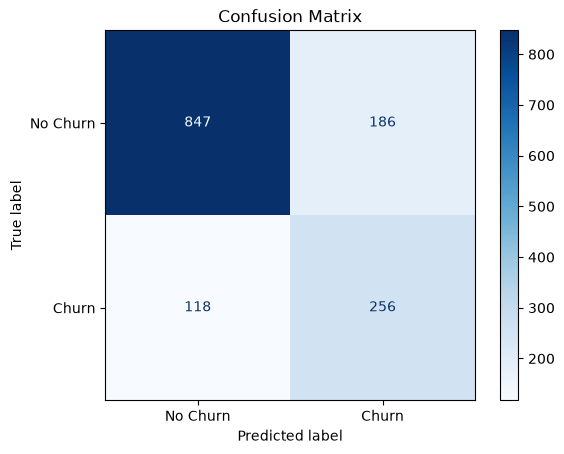

In [195]:
# confusion matrix

from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt


cm = confusion_matrix(y_test, y_pred_final)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn","Churn"]
).plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.show()

Confusion Matrix

The confusion matrix summarizes the classification performance of the model.

In customer churn prediction, False Negatives are generally more costly than False Positives because failing to identify a customer who is likely to churn may result in customer loss. Therefore, improving recall is often prioritized.

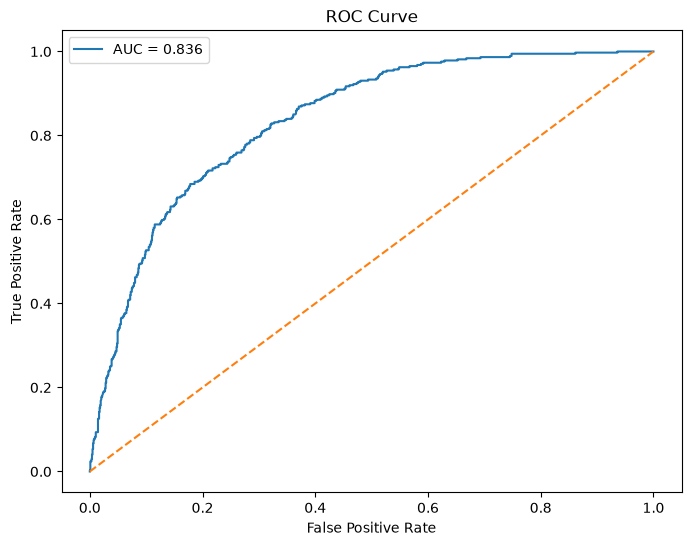

In [197]:
# roc curve 

from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8,6))
plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc_score(y_test,y_prob):.3f}"
)
plt.plot(
    [0,1],
    [0,1],
    "--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

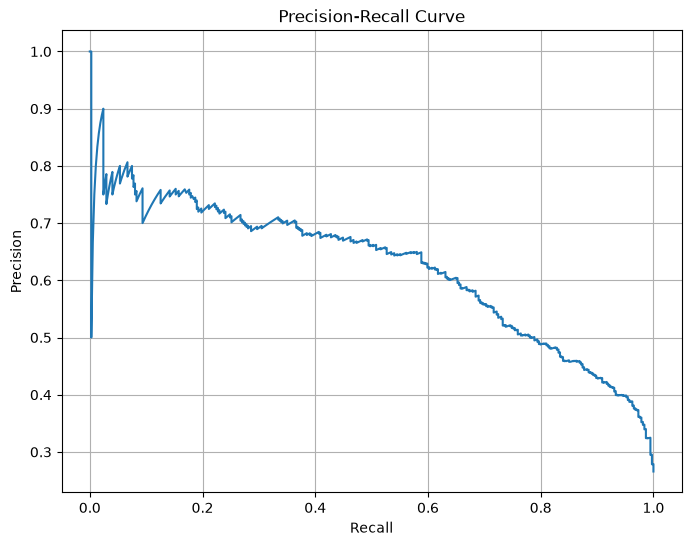

In [198]:
# Precision-Recall Curve

from sklearn.metrics import precision_recall_curve
precision, recall, _ = precision_recall_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8,6))

plt.plot(
    recall,
    precision
)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.grid(True)

plt.show()

In [200]:
# Now lets check how strongly a feature influences the prediction

feature_names = preprocessor.get_feature_names_out()
coefficients = lr.coef_[0]

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

feature_importance["Absolute_Coefficient"] = feature_importance["Coefficient"].abs()

feature_importance = feature_importance.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

feature_importance.head(15)

,Feature,Coefficient,Absolute_Coefficient
1,num__tenure,-1.352313,1.352313
38,cat__Contract_Two year,-0.779030,0.779030
3,num__TotalCharges,0.644014,0.644014
15,cat__InternetService_DSL,-0.616132,0.616132
36,cat__Contract_Month-to-month,0.613846,0.613846
16,cat__InternetService_Fiber optic,0.590184,0.590184
2,num__MonthlyCharges,-0.541006,0.541006
39,cat__PaperlessBilling_No,-0.300387,0.300387
12,cat__MultipleLines_No,-0.293470,0.293470
22,cat__OnlineBackup_No internet service,-0.283724,0.283724


Feature Importance Insights

The Logistic Regression coefficients indicate that customer tenure and contract type are among the strongest predictors of churn. Longer tenure and two-year contracts are associated with lower churn risk, while month-to-month contracts and fiber optic internet service are associated with higher churn risk.

These findings are consistent with the patterns observed during exploratory data analysis. Some correlated features, such as tenure, monthly charges, and total charges, should be interpreted cautiously because their individual coefficients may be influenced by multicollinearity.

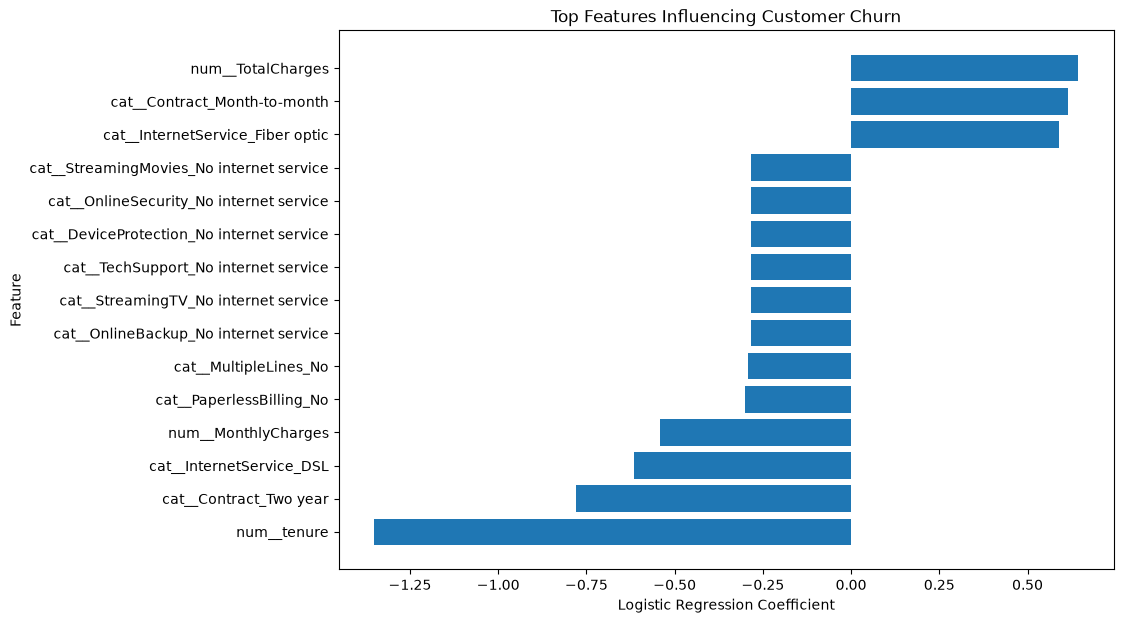

In [ ]:



top_features = feature_importance.head(15).sort_values(
    by="Coefficient"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Top Features Influencing Customer Churn")

plt.show()

Background dataset has 5625 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=5625 when initializing the masker.


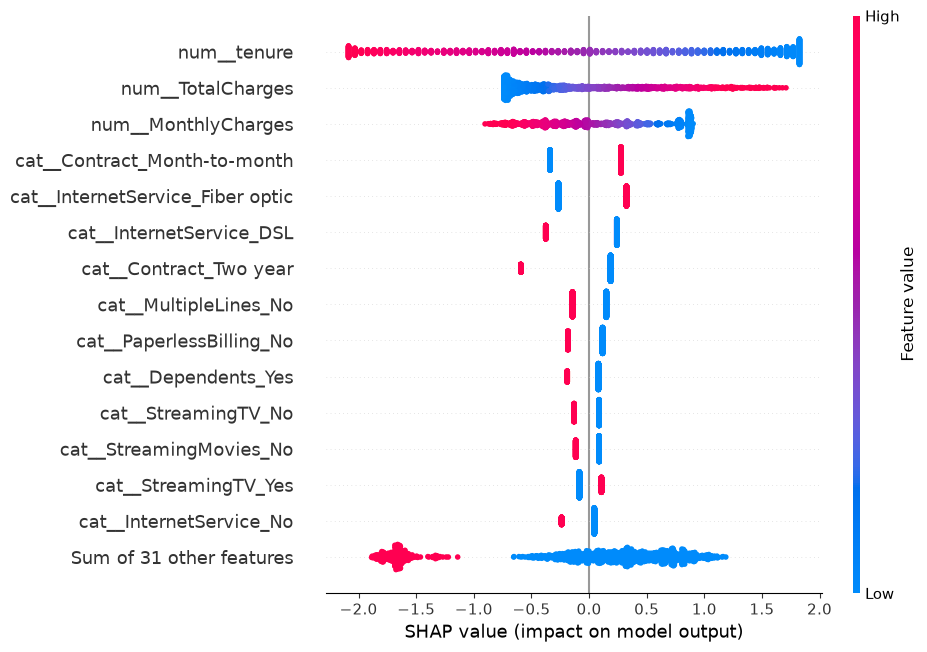

In [203]:
import shap

feature_names = preprocessor.get_feature_names_out()

X_train_shap = pd.DataFrame(
    X_train_processed,
    columns=feature_names
)

X_test_shap = pd.DataFrame(
    X_test_processed,
    columns=feature_names
)

explainer = shap.LinearExplainer(
    lr,
    X_train_processed
)

shap_values = explainer(X_test_shap)
feature_names = preprocessor.get_feature_names_out()


shap.plots.beeswarm(
    shap_values,
    max_display=15
)

SHAP Global Explainability

The SHAP summary plot shows that tenure is the strongest driver of churn predictions. Customers with lower tenure are more likely to be classified as high churn risk, while longer-tenured customers are pushed toward non-churn predictions.

Month-to-month contracts and fiber optic internet service increase predicted churn risk, whereas two-year contracts and DSL service reduce it. These findings are broadly consistent with the patterns observed during exploratory data analysis.

Customer index: 1149
Churn probability: 0.8474657995950894


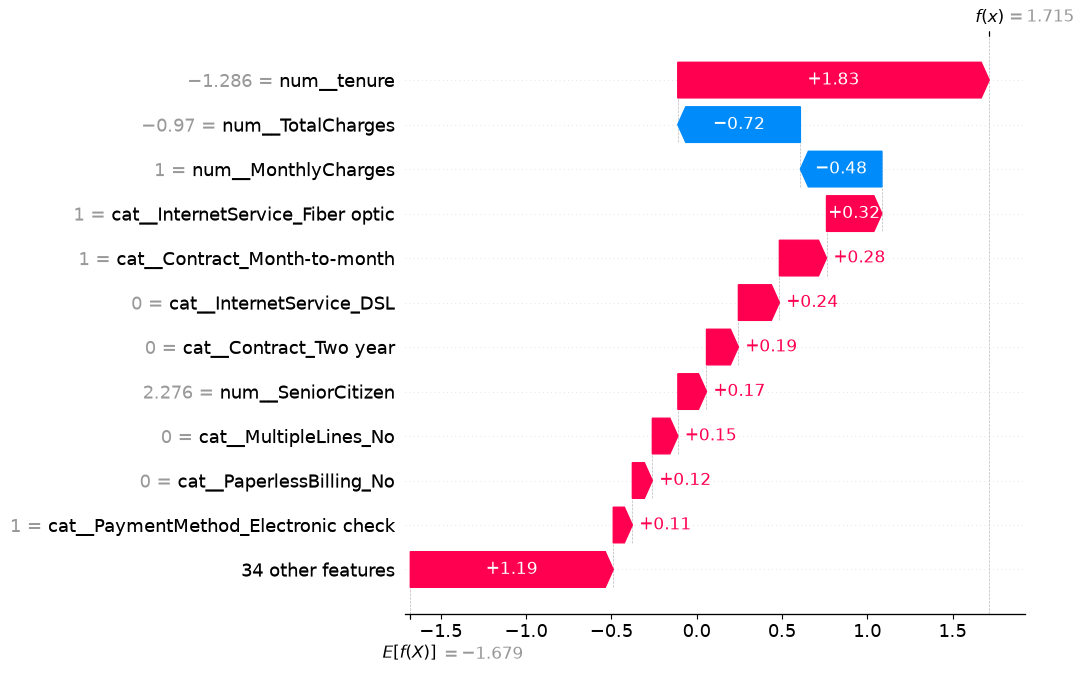

In [204]:
high_risk_index = np.argmax(y_prob)

print("Customer index:", high_risk_index)
print("Churn probability:", y_prob[high_risk_index])

shap.plots.waterfall(
    shap_values[high_risk_index],
    max_display=12
)

In [205]:
print(
    f"Predicted churn probability: {y_prob[high_risk_index]:.2%}"
)

Predicted churn probability: 84.75%


Local SHAP Explanation

The highest-risk customer in the test set has a predicted churn probability of 84.75%. The strongest factor increasing churn risk is low customer tenure, followed by fiber optic internet service and a month-to-month contract.

Although some features, including total charges and monthly charges, reduce the predicted churn risk, they are outweighed by the customer's stronger positive churn drivers.

In [214]:
# save to model.pkl

import joblib
import os

os.makedirs("../artifacts", exist_ok=True)

feature_names = preprocessor.get_feature_names_out()

artifact = {
    "model": lr,
    "preprocessor": preprocessor,
    "threshold": 0.40,
    "feature_names": feature_names
}

joblib.dump(artifact, "../artifacts/model.pkl")

['../artifacts/model.pkl']

In [ ]:
#Test Saved Prediction Pipeline

sample_customer = X_test.iloc[0].to_dict()

sample_customer

{'gender': 'Female',
 'SeniorCitizen': 0,
 'Partner': 'Yes',
 'Dependents': 'Yes',
 'tenure': 59,
 'PhoneService': 'Yes',
 'MultipleLines': 'No',
 'InternetService': 'DSL',
 'OnlineSecurity': 'No',
 'OnlineBackup': 'Yes',
 'DeviceProtection': 'No',
 'TechSupport': 'Yes',
 'StreamingTV': 'Yes',
 'StreamingMovies': 'Yes',
 'Contract': 'Two year',
 'PaperlessBilling': 'Yes',
 'PaymentMethod': 'Credit card (automatic)',
 'MonthlyCharges': 75.95,
 'TotalCharges': 4542.35}

In [212]:
import sys
from pathlib import Path

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.predict import predict_churn

result = predict_churn(sample_customer)

result

{'prediction': 0, 'churn_probability': 0.017513027676195458, 'threshold': 0.4}